In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import ortho_group, beta

In [2]:
def random_covariance_matrix_beta(p, a, b):
    lambdas = np.random.beta(a, b, size = p)

    Lambda = np.diag(lambdas)

    Q = ortho_group.rvs(dim = p)

    error = np.linalg.norm(Q.T @ Q - np.eye(p))

    print("Orthogonality error:", error)

    Sigma = Q @ Lambda @ Q.T

    return Sigma

In [3]:
def random_covariance_matrix_wielomian(p, b, alpha):
    lam_unif = np.random.uniform(0, 1, p)
    lambdas = b * lam_unif**(1/(alpha + 1))

    Lambda = np.diag(lambdas)

    A = np.random.randn(p, p)
    Q, _ = np.linalg.qr(A)

    Sigma = Q @ Lambda @ Q.T

    return Sigma
    

In [4]:
def random_covariance_matrix_inny(p, a, b):
    U = np.random.uniform(0, 1, p)
    lambdas = (1 - (1 - U)**(1/b))**(1/a)
    Lambda = np.diag(lambdas)
    A = np.random.randn(p, p)
    Q, _ = np.linalg.qr(A)

    Sigma = Q @ Lambda @ Q.T

    return Sigma

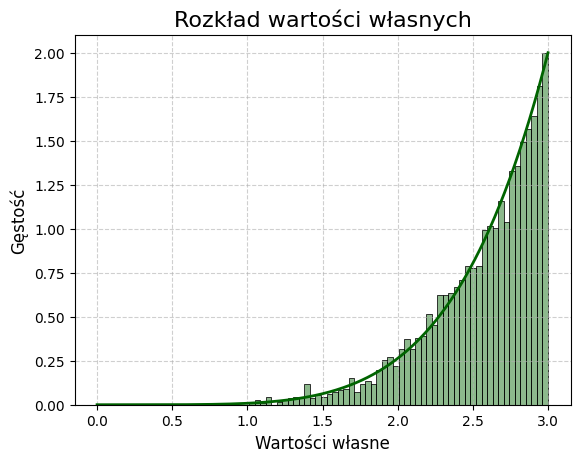

In [83]:
Sigma = random_covariance_matrix_wielomian(3000, 3, 5)
sns.histplot(np.linalg.eigvalsh(Sigma), bins = 60, kde = False, stat = "density",
            color = "darkgreen", alpha = 0.45)
#x = np.linspace(0, 1, 1000)

#y = beta.pdf(x, a=0.5, b=0.5)

#plt.plot(x, y, color="darkgreen", linewidth=2)
x = np.linspace(0, 3, 1000)
y = ((5 + 1) / (3**(5 + 1))) * x**5

plt.plot(
    x,
    y,
    color="darkgreen",
    linewidth=2
)

plt.title("Rozkład wartości własnych", fontsize = 16)
plt.xlabel("Wartości własne", fontsize = 12)
plt.ylabel("Gęstość", fontsize = 12)
plt.grid(True, linestyle = "--", alpha = 0.6)
plt.savefig("wykres_oryg_beta_nggp.png")

In [84]:
n = 200
p = Sigma.shape[0]
mu = np.zeros(p)

X = np.random.multivariate_normal(mu, Sigma, size = n)

In [85]:
#Estymator S_n
Sn = (1 / n) * (X.T @ X)
np.shape(Sn)

(3000, 3000)

In [86]:
eigvals = np.linalg.eigvalsh(Sn)
eig_nonzero = eigvals[eigvals > 1e-15]

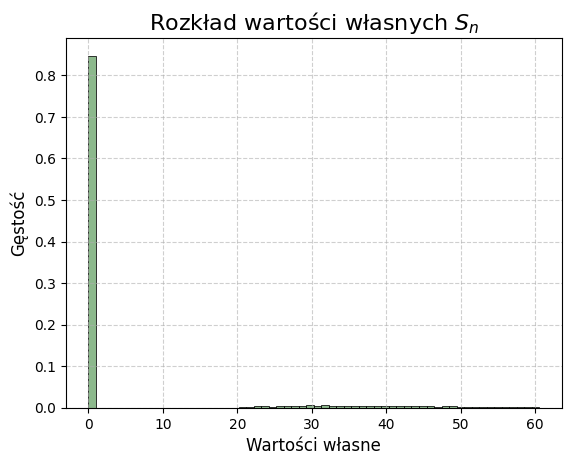

In [87]:
sns.histplot(eig_nonzero, bins = 60, kde = False, stat = "density",
            color = "darkgreen", alpha = 0.45)
plt.title(r"Rozkład wartości własnych $S_n$", fontsize = 16)
plt.xlabel("Wartości własne", fontsize = 12)
plt.ylabel("Gęstość", fontsize = 12)
plt.grid(True, linestyle = "--", alpha = 0.6)
plt.savefig("wykres_Sn_beta_nggp")

In [89]:
k = int(n -  10*np.sqrt(n))
X1 = X[:k, :]
X2 = X[k:, :]
k

58

In [90]:
Sigma1 = 1/(k) * (X1.T @ X1)
Sigma2 = 1/(n-k) * (X2.T @ X2)

In [91]:
eigvals1, P1 = np.linalg.eigh(Sigma1)

In [92]:
M = P1.T @ Sigma2 @ P1
D = np.diag(np.diag(M))
EST = P1 @ D @ P1.T

eigvalEST = np.linalg.eigvalsh(EST)
eigvalEST_nonzero = eigvalEST[eigvalEST > 1e-15]

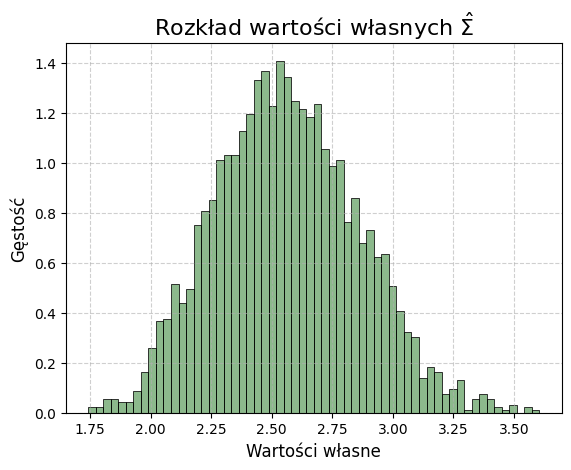

In [93]:
sns.histplot(eigvalEST_nonzero, bins = 60, kde = False, stat = "density",
            color = "darkgreen", alpha = 0.45)
plt.title(r"Rozkład wartości własnych $\hat{\Sigma}$", fontsize = 16)
plt.xlabel("Wartości własne", fontsize = 12)
plt.ylabel("Gęstość", fontsize = 12)
#plt.xlim(2,3.5)
plt.grid(True, linestyle = "--", alpha = 0.6)
plt.savefig("wykres_EST_beta_nggp")

In [94]:
np.linalg.norm(Sn - Sigma, ord = "fro")

543.4476045112671

In [95]:
np.linalg.norm(EST - Sigma, ord = "fro")

26.09520671604216

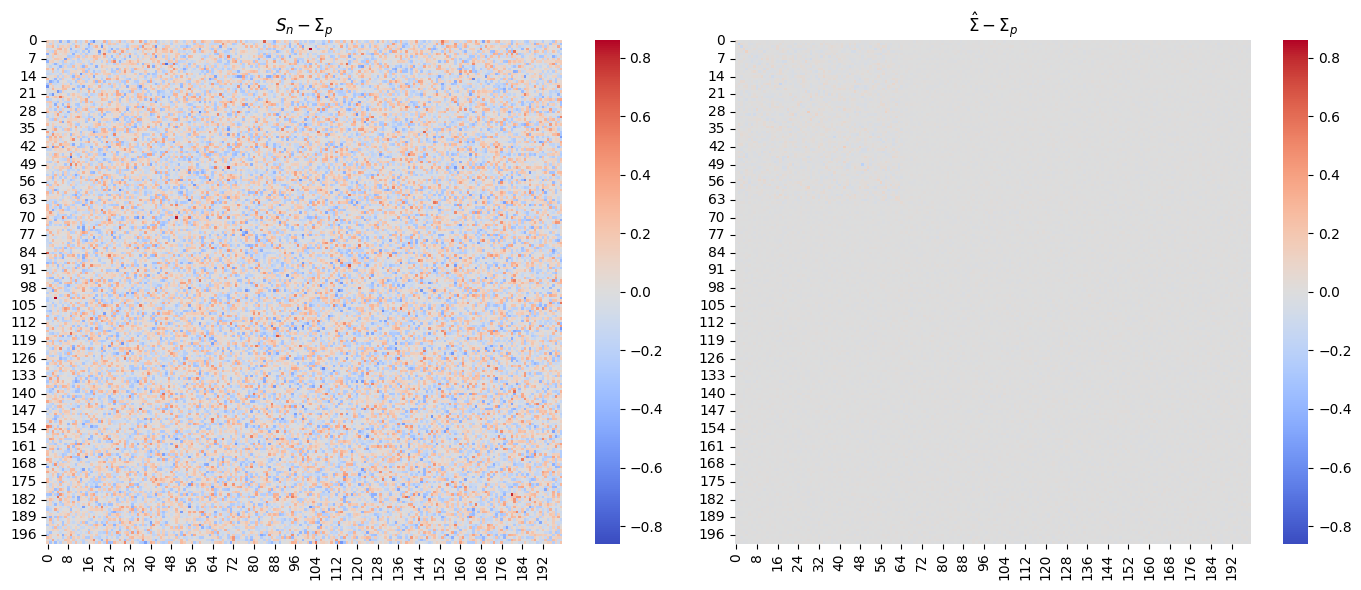

In [96]:
subset = 200

diff_EST = EST - Sigma
diff_Sn = Sn - Sigma

diff_EST_small = diff_EST[:subset, :subset]
diff_Sn_small = diff_Sn[:subset, :subset]

vmax = max(
    np.abs(diff_EST_small).max(),
    np.abs(diff_Sn_small).max()
)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.heatmap(diff_Sn_small,
            ax=axes[0],
            cmap="coolwarm",
            vmin=-vmax,
            vmax=vmax,
            center=0)

axes[0].set_title(r"$S_n - \Sigma_{p}$")

sns.heatmap(diff_EST_small,
            ax=axes[1],
            cmap="coolwarm",
            vmin=-vmax,
            vmax=vmax,
            center=0)

axes[1].set_title(r"$\hat{\Sigma} - \Sigma_{p}$")

plt.tight_layout()
plt.savefig("heatmap_beta_nggp")
plt.show()

In [97]:
eig_ideal, P = np.linalg.eigh(Sn)
H = P.T @ Sigma @ P
D = np.diag(np.diag(H))
Sigma_ideal = P @ D @ P.T
eps = 1e-6
err_ideal = np.linalg.norm(Sigma_ideal - Sigma, 'fro')**2
err_Sn = np.linalg.norm(Sn - Sigma, 'fro')**2
err_EST = np.linalg.norm(EST - Sigma, 'fro')**2



SE_Sn = 1 - err_ideal / (err_Sn)
SE_EST = 1 - err_ideal / (err_EST)
print(SE_Sn)
print(SE_EST)
print(err_ideal)
print(err_Sn)
print(err_EST)

0.9985780190387786
0.3832805346489535
419.96117213993705
295335.29884903453
680.9598135529718
